# Phase 1 — Baselines for Non-IID Federated LLMs

Five arms, identical LoRA init, **matched compute**, same eval sets — the three comparisons the proposal (Section 4) calls for, plus a base reference and a value-of-FL arm:

| Arm | What it answers |
|---|---|
| **base** (round 0) | anchor — how much did anything move from untuned Qwen? |
| **centralized** | upper bound — all data pooled in one place |
| **IID-FL** | ideal FL — 4 domains shuffled + re-split across clients |
| **non-IID-FL** | the treatment — one domain per client |
| **local-only** | is federating worth joining? each client trains solo |

**Matched budget:** each FL client does `rounds × local_steps` gradient steps; the whole federation does `rounds × local_steps × n_clients`. Centralized gets that same total on pooled data; each local-only model gets one client's share.

Outputs a single summary table, the **IID-vs-non-IID gap** per domain (the hypothesis plot), and the **IID-vs-non-IID cosine** contrast that finally makes the alignment metric interpretable.

Kaggle: **Internet On**, **GPU On**. ~5× the single-arm runtime — comfortably one session at these light settings.

## 1 · Install (removes Kaggle's torchao 0.10, which crashes PEFT LoRA)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.run([sys.executable, "-m", "pip", *a])
_pip("install", "-q", "transformers>=4.44", "peft>=0.12", "datasets>=2.20", "accelerate>=0.33")
_pip("uninstall", "-y", "torchao")
print("\nIf torchao was already imported this session: Run -> Restart, then Run All.")


If torchao was already imported this session: Run -> Restart, then Run All.


## 2 · Imports

In [2]:
import os, math, copy, random, itertools, warnings
from dataclasses import dataclass, field
from typing import List
import numpy as np, pandas as pd, torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, get_peft_model_state_dict, set_peft_model_state_dict
warnings.filterwarnings("ignore")

## 3 · Config

In [3]:
@dataclass
class Config:
    model_id: str = "Qwen/Qwen2.5-0.5B-Instruct"
    seed: int = 42
    clients: List[tuple] = field(default_factory=lambda: [
        ("general", "vicgalle/alpaca-gpt4"),
        ("finance", "FinGPT/fingpt-sentiment-train"),
        ("medical", "medalpaca/medical_meadow_medical_flashcards"),
        ("coding",  "sahil2801/CodeAlpaca-20k"),
    ])
    num_rounds: int = 8
    local_steps: int = 40
    batch_size: int = 4
    eval_batch_size: int = 8
    lr: float = 2e-4
    max_len: int = 512
    train_per_client: int = 1000
    eval_per_client: int = 200
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.05
    lora_targets: List[str] = field(default_factory=lambda: ["q_proj", "v_proj"])
    weighted_fedavg: bool = True
    out_dir: str = "/kaggle/working"

cfg = Config()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(cfg.out_dir, exist_ok=True)
def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(cfg.seed)
print("device:", DEVICE)

device: cuda


## 4 · Model + captured base LoRA init
`base_lora_sd` (B=0 → behaves as the untuned base model) is the identical starting point every arm resets to, so the comparison is fair.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(cfg.model_id)
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
base_model = AutoModelForCausalLM.from_pretrained(
    cfg.model_id, torch_dtype=torch.float16 if DEVICE=="cuda" else torch.float32)
lora_cfg = LoraConfig(r=cfg.lora_r, lora_alpha=cfg.lora_alpha, lora_dropout=cfg.lora_dropout,
                      target_modules=cfg.lora_targets, task_type="CAUSAL_LM", bias="none")
model = get_peft_model(base_model, lora_cfg).to(DEVICE)
model.print_trainable_parameters()
GLOBAL_KEYS = sorted(get_peft_model_state_dict(model).keys())
base_lora_sd = {k: v.detach().cpu().clone() for k, v in get_peft_model_state_dict(model).items()}

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 1,081,344 || all params: 495,114,112 || trainable%: 0.2184


## 5 · Data: per-domain, pooled, IID re-split, uniform eval, unseen OOD

In [5]:
def _get(ex, *names):
    for n in names:
        v = ex[n] if n in ex else None
        if v is not None and str(v).strip(): return str(v).strip()
    return ""

def build_example(ex, stats=None):
    instr = _get(ex, "instruction", "question", "prompt", "Question")
    inp   = _get(ex, "input", "context")
    out   = _get(ex, "output", "answer", "response", "completion", "text")
    if not out:
        if stats is not None: stats["no_output"] += 1
        return None
    user = instr if not inp else f"{instr}\n\n{inp}"
    if not user:
        if stats is not None: stats["no_user"] += 1
        return None
    try:
        ptext = tokenizer.apply_chat_template([{"role":"user","content":user}],
                                              tokenize=False, add_generation_prompt=True)
    except Exception:
        ptext = f"### Instruction:\n{user}\n\n### Response:\n"
    pids = tokenizer(ptext, add_special_tokens=False)["input_ids"]
    rids = tokenizer(out, add_special_tokens=False)["input_ids"] + [tokenizer.eos_token_id]
    ids  = (pids + rids)[:cfg.max_len]
    lbl  = ([-100]*len(pids) + rids)[:cfg.max_len]
    if all(t == -100 for t in lbl):
        if stats is not None: stats["truncated"] += 1
        return None
    return {"input_ids": ids, "labels": lbl}

def load_client(domain, repo, n_train, n_eval):
    ds = load_dataset(repo, split="train").shuffle(seed=cfg.seed)
    ds = ds.select(range(min(len(ds), n_train + n_eval)))
    stats = {"no_output":0,"no_user":0,"truncated":0}
    rows = [b for ex in ds if (b := build_example(ex, stats))]
    if not rows:
        print(f"  [{domain}] 0 usable! columns={ds.column_names} skips={stats}")
    random.shuffle(rows)
    tr, ev = rows[:n_train], rows[n_train:n_train+n_eval]
    print(f"  [{domain:8s}] {repo:45s} train={len(tr)} eval={len(ev)}")
    return {"domain": domain, "train": tr, "eval": ev}

def load_eval_only(repo, n, config=None):
    ds = (load_dataset(repo, config, split="train") if config else load_dataset(repo, split="train"))
    ds = ds.shuffle(seed=cfg.seed).select(range(min(len(ds), n)))
    return [b for ex in ds if (b := build_example(ex))]

print("Loading clients ...")
CLIENTS = [load_client(d, r, cfg.train_per_client, cfg.eval_per_client) for d, r in cfg.clients]
NUM_CLIENTS = len(CLIENTS)

# non-IID partition = one domain per client
noniid_trains = [c["train"] for c in CLIENTS]
# pooled + IID re-split across the same number of clients
pooled_train = [x for c in CLIENTS for x in c["train"]]
random.Random(cfg.seed).shuffle(pooled_train)
shard = len(pooled_train)//NUM_CLIENTS
iid_trains = [pooled_train[i*shard:(i+1)*shard] for i in range(NUM_CLIENTS)]
# eval sets
UNIFORM_EVAL = [x for c in CLIENTS for x in c["eval"]]
OOD_EVAL = load_eval_only("openai/gsm8k", cfg.eval_per_client, config="main")   # unseen domain
print(f"pooled={len(pooled_train)} iid_shards={[len(s) for s in iid_trains]} "
      f"uniform_eval={len(UNIFORM_EVAL)} ood_eval={len(OOD_EVAL)}")

Loading clients ...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-6ef3991c06080e(…):   0%|          | 0.00/48.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

  [general ] vicgalle/alpaca-gpt4                          train=1000 eval=200


...

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

pooled=4000 iid_shards=[1000, 1000, 1000, 1000] uniform_eval=784 ood_eval=200


## 6 · Batching + core helpers

In [6]:
def collate(batch):
    m = max(len(b["input_ids"]) for b in batch); pad = tokenizer.pad_token_id
    ids, lbl, att = [], [], []
    for b in batch:
        p = m - len(b["input_ids"])
        ids.append(b["input_ids"]+[pad]*p); lbl.append(b["labels"]+[-100]*p)
        att.append([1]*len(b["input_ids"])+[0]*p)
    return torch.tensor(ids), torch.tensor(lbl), torch.tensor(att)

def batches(data, bs, shuffle=True):
    idx = list(range(len(data)))
    if shuffle: random.shuffle(idx)
    for i in range(0, len(idx), bs):
        yield collate([data[j] for j in idx[i:i+bs]])

def set_global(sd): set_peft_model_state_dict(model, {k:v.to(DEVICE) for k,v in sd.items()})
def get_global():   return {k:v.detach().cpu().clone() for k,v in get_peft_model_state_dict(model).items()}
def flatten(sd, keys): return torch.cat([sd[k].flatten().float() for k in keys])

def fedavg(states, weights):
    w = torch.tensor(weights, dtype=torch.float32); w = w/w.sum()
    return {k: sum(states[i][k].float()*w[i] for i in range(len(states))).to(states[0][k].dtype)
            for k in GLOBAL_KEYS}

def local_train(init_sd, data, steps, lr):
    set_global(init_sd); model.train()
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr)
    it = itertools.cycle(batches(data, cfg.batch_size)); run = 0.0
    for _ in range(steps):
        ids, lbl, att = next(it); ids,lbl,att = ids.to(DEVICE),lbl.to(DEVICE),att.to(DEVICE)
        out = model(input_ids=ids, attention_mask=att, labels=lbl)
        opt.zero_grad(); out.loss.backward(); opt.step(); run += out.loss.item()
    return get_global(), run/steps

@torch.no_grad()
def evaluate(sd, data):
    set_global(sd); model.eval(); tl, tt = 0.0, 0
    for ids, lbl, att in batches(data, cfg.eval_batch_size, shuffle=False):
        ids,lbl,att = ids.to(DEVICE),lbl.to(DEVICE),att.to(DEVICE)
        out = model(input_ids=ids, attention_mask=att, labels=lbl)
        n = (lbl != -100).sum().item(); tl += out.loss.item()*n; tt += n
    l = tl/max(tt,1); return l, math.exp(min(l,20))

def eval_all(sd):
    d = {c["domain"]: evaluate(sd, c["eval"])[0] for c in CLIENTS}
    d["uniform"]  = evaluate(sd, UNIFORM_EVAL)[0]
    d["ood_math"] = evaluate(sd, OOD_EVAL)[0]
    return d

## 7 · Arm runners

In [7]:
def run_federated(client_trains, tag):
    g = {k:v.clone() for k,v in base_lora_sd.items()}
    rows = []
    for rnd in range(1, cfg.num_rounds+1):
        locals_, weights, updates = [], [], []
        for tr in client_trains:
            ls, _ = local_train(g, tr, cfg.local_steps, cfg.lr)
            locals_.append(ls); weights.append(len(tr) if cfg.weighted_fedavg else 1)
            updates.append(flatten(ls, GLOBAL_KEYS) - flatten(g, GLOBAL_KEYS))
        cos = [F.cosine_similarity(updates[i][None], updates[j][None]).item()
               for i,j in itertools.combinations(range(len(client_trains)),2)]
        g = fedavg(locals_, weights)
        ev = eval_all(g)
        rows.append({"round":rnd, "mean_cos":float(np.mean(cos)),
                     **{f"eval_{k}":v for k,v in ev.items()}})
        print(f"  [{tag}] r{rnd:2d} uniform={ev['uniform']:.3f} ood={ev['ood_math']:.3f} cos={np.mean(cos):+.3f}")
    return g, pd.DataFrame(rows)

def run_centralized(train):
    total = cfg.num_rounds * cfg.local_steps * NUM_CLIENTS
    sd, _ = local_train(base_lora_sd, train, total, cfg.lr)
    print(f"  [centralized] {total} steps on pooled data"); return sd

def run_local_only(client_trains):
    steps = cfg.num_rounds * cfg.local_steps; outs = []
    for c, tr in zip(CLIENTS, client_trains):
        sd, _ = local_train(base_lora_sd, tr, steps, cfg.lr)
        outs.append(sd); print(f"  [local-only:{c['domain']}] {steps} steps")
    return outs

## 8 · Run all five arms

In [8]:
print("BASE (round 0)"); base_eval = eval_all(base_lora_sd)
print("\nNON-IID FL");     g_noniid, log_noniid = run_federated(noniid_trains, "noniid")
print("\nIID FL");         g_iid,    log_iid    = run_federated(iid_trains,    "iid")
print("\nCENTRALIZED");    sd_cent = run_centralized(pooled_train)
print("\nLOCAL-ONLY");     local_sds = run_local_only(noniid_trains)

BASE (round 0)

NON-IID FL
  [noniid] r 1 uniform=1.168 ood=0.693 cos=+0.068
  [noniid] r 2 uniform=1.163 ood=0.676 cos=+0.009
  [noniid] r 3 uniform=1.160 ood=0.667 cos=-0.010
  [noniid] r 4 uniform=1.160 ood=0.658 cos=-0.010
  [noniid] r 5 uniform=1.158 ood=0.655 cos=-0.009
  [noniid] r 6 uniform=1.156 ood=0.656 cos=-0.011
  [noniid] r 7 uniform=1.154 ood=0.661 cos=-0.006
  [noniid] r 8 uniform=1.154 ood=0.660 cos=-0.009

IID FL
  [iid] r 1 uniform=1.164 ood=0.699 cos=+0.221
  [iid] r 2 uniform=1.158 ood=0.684 cos=+0.060
  [iid] r 3 uniform=1.155 ood=0.690 cos=+0.036
  [iid] r 4 uniform=1.154 ood=0.687 cos=+0.041
  [iid] r 5 uniform=1.151 ood=0.673 cos=+0.024
  [iid] r 6 uniform=1.149 ood=0.674 cos=+0.013
  [iid] r 7 uniform=1.148 ood=0.660 cos=+0.018
  [iid] r 8 uniform=1.147 ood=0.662 cos=+0.005

CENTRALIZED
  [centralized] 1280 steps on pooled data

LOCAL-ONLY
  [local-only:general] 320 steps
  [local-only:finance] 320 steps
  [local-only:medical] 320 steps
  [local-only:coding] 3

## 9 · Summary table

In [9]:
cols = [c["domain"] for c in CLIENTS] + ["uniform", "ood_math"]
rows = {}
rows["base"]        = base_eval
rows["centralized"] = eval_all(sd_cent)
rows["iid_fl"]      = eval_all(g_iid)
rows["noniid_fl"]   = eval_all(g_noniid)
# local-only: own-specialist per domain; specialist-mean for uniform/ood (no single local model spans them)
lo = {c["domain"]: evaluate(sd, c["eval"])[0] for c, sd in zip(CLIENTS, local_sds)}
lo["uniform"]  = float(np.mean([evaluate(sd, UNIFORM_EVAL)[0] for sd in local_sds]))
lo["ood_math"] = float(np.mean([evaluate(sd, OOD_EVAL)[0] for sd in local_sds]))
rows["local_only"] = lo

summary = pd.DataFrame(rows).T[cols].round(4)
summary.to_csv(f"{cfg.out_dir}/phase1_summary.csv")
print("held-out loss (lower = better)\n"); print(summary)
print("\nimprovement vs base (negative = better):\n")
print((summary - summary.loc["base"]).round(4))

held-out loss (lower = better)

             general  finance  medical  coding  uniform  ood_math
base          1.4101   2.3944   1.2101  0.8385   1.2592    0.7791
centralized   1.3912   0.4233   1.0661  0.6144   1.1506    0.6520
iid_fl        1.3843   0.3574   1.0708  0.6113   1.1467    0.6625
noniid_fl     1.3896   0.3191   1.0885  0.6149   1.1544    0.6603
local_only    1.3804   0.2903   1.0703  0.6059   1.1969    0.6947

improvement vs base (negative = better):

             general  finance  medical  coding  uniform  ood_math
base          0.0000   0.0000   0.0000  0.0000   0.0000    0.0000
centralized  -0.0189  -1.9711  -0.1440 -0.2241  -0.1086   -0.1271
iid_fl       -0.0258  -2.0370  -0.1393 -0.2272  -0.1125   -0.1166
noniid_fl    -0.0205  -2.0753  -0.1216 -0.2236  -0.1048   -0.1188
local_only   -0.0297  -2.1041  -0.1398 -0.2326  -0.0623   -0.0844


## 10 · The hypothesis plot — IID vs non-IID gap per domain
Bars near zero mean domain non-IID is **not** materially more severe than IID FL (supports the symmetry claim).

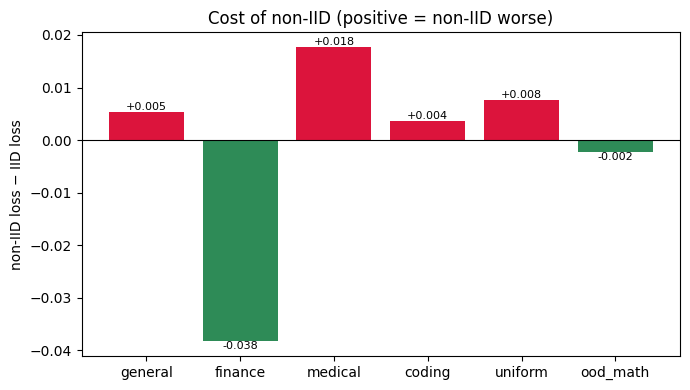

In [10]:
seen = [c["domain"] for c in CLIENTS]
gap = (summary.loc["noniid_fl"] - summary.loc["iid_fl"])[seen + ["uniform", "ood_math"]]
plt.figure(figsize=(7,4))
b = plt.bar(gap.index, gap.values,
            color=["crimson" if v>0 else "seagreen" for v in gap.values])
plt.axhline(0, color="k", lw=.8)
plt.ylabel("non-IID loss − IID loss"); plt.title("Cost of non-IID (positive = non-IID worse)")
for r,v in zip(b, gap.values): plt.text(r.get_x()+r.get_width()/2, v, f"{v:+.3f}",
            ha="center", va="bottom" if v>=0 else "top", fontsize=8)
plt.tight_layout(); plt.savefig(f"{cfg.out_dir}/plot_iid_gap.png", dpi=130); plt.show()

## 11 · Summary heatmap — improvement over base

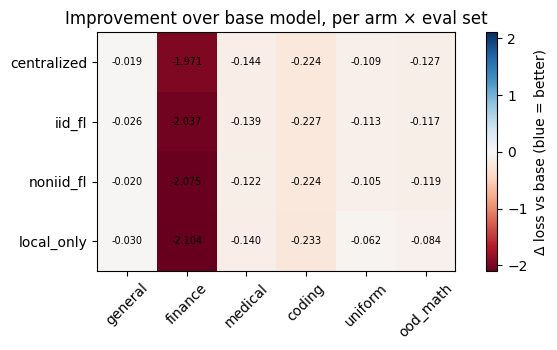

In [11]:
delta = (summary - summary.loc["base"]).drop(index="base")
plt.figure(figsize=(7, 3.6))
lim = np.abs(delta.values).max()
plt.imshow(delta.values, cmap="RdBu", vmin=-lim, vmax=lim)
plt.colorbar(label="Δ loss vs base (blue = better)")
plt.xticks(range(len(cols)), cols, rotation=45); plt.yticks(range(len(delta)), delta.index)
for i in range(delta.shape[0]):
    for j in range(delta.shape[1]):
        plt.text(j, i, f"{delta.values[i,j]:+.3f}", ha="center", va="center", fontsize=7)
plt.title("Improvement over base model, per arm × eval set")
plt.tight_layout(); plt.savefig(f"{cfg.out_dir}/plot_summary_delta.png", dpi=130); plt.show()

## 12 · The metric that was uninterpretable before — IID vs non-IID update cosine
Under IID, clients share an objective, so updates should be **more** aligned than under non-IID. The gap between these two curves is the real 'how much does heterogeneity misalign updates' signal.

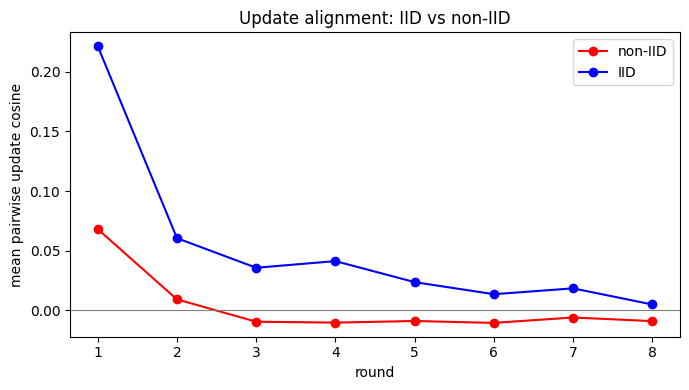

In [12]:
plt.figure(figsize=(7,4))
plt.plot(log_noniid["round"], log_noniid["mean_cos"], "r-o", label="non-IID")
plt.plot(log_iid["round"],    log_iid["mean_cos"],    "b-o", label="IID")
plt.axhline(0, color="grey", lw=.8)
plt.xlabel("round"); plt.ylabel("mean pairwise update cosine")
plt.title("Update alignment: IID vs non-IID"); plt.legend()
plt.tight_layout(); plt.savefig(f"{cfg.out_dir}/plot_cos_contrast.png", dpi=130); plt.show()

## 13 · Value-of-FL ladder on the generalization sets

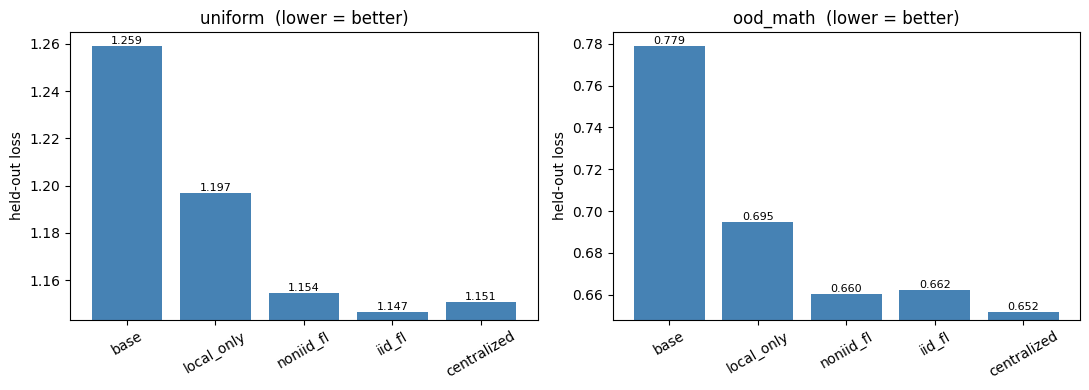

Saved: phase1_summary.csv + 4 figures in /kaggle/working


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
order = ["base", "local_only", "noniid_fl", "iid_fl", "centralized"]
for ax, metric in zip(axes, ["uniform", "ood_math"]):
    vals = [summary.loc[a, metric] for a in order]
    bars = ax.bar(order, vals, color="steelblue")
    ax.set_title(f"{metric}  (lower = better)"); ax.set_ylabel("held-out loss")
    ax.tick_params(axis="x", rotation=30)
    lo_v, hi_v = min(vals), max(vals); ax.set_ylim(lo_v-0.03*(hi_v-lo_v+1e-9), hi_v+0.05*(hi_v-lo_v+1e-9))
    for b,v in zip(bars, vals): ax.text(b.get_x()+b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.savefig(f"{cfg.out_dir}/plot_value_of_fl.png", dpi=130); plt.show()
print("Saved: phase1_summary.csv + 4 figures in", cfg.out_dir)